In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict


c:\Programs12\AI_Labs\AI-Labs\venv\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [3]:
llm=ChatOllama(
    model="llama3.2",
    temperature=0.5
)

In [4]:
model=ChatOllama(model='llama3.2')

In [5]:
class Blogstate(TypedDict):
    content:str
    outline:str
    title:str

In [6]:
def create_outline(state:Blogstate)->Blogstate:
    #fetch title
    title=state['title']
    #call llm gen outline
    prompt=f"Generate a detailed outline for a blog on the topic -{title}"
    outline=model.invoke(prompt)
    #update state
    state['outline']=outline
    return state

In [8]:
def create_blog(state:Blogstate)->Blogstate:
    title=state['title']
    outline=state['outline']
    prompt=f"Write a detailed blog on the title -{title} using the folloeing outline \n {outline}"
    content=model.invoke(prompt).content
    state['content']=content
    return state

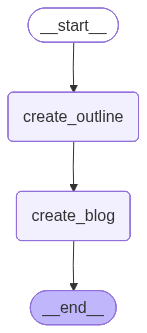

In [12]:
graph=StateGraph(Blogstate)
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)
workflow=graph.compile()

In [14]:
intial_state={"title":"Rise of AI in India"}
output_state=workflow.invoke(intial_state)
print(output_state)

{'content': "The Rise of Artificial Intelligence in India: Trends, Challenges, and Opportunities\n\nIntroduction\n\nArtificial intelligence (AI) has revolutionized the way we live, work, and interact with each other. The Indian government has set ambitious targets to become a leading player in the global AI landscape, recognizing its potential to transform industries, drive economic growth, and improve quality of life. As AI continues to gain traction in India, it's essential to understand the trends, challenges, and opportunities that are shaping this rapidly evolving field.\n\nCurrent State of AI in India\n\nIndia has made significant strides in AI adoption across various sectors, including healthcare, finance, education, and more. Key players such as Google, Microsoft, and IBM have established a strong presence in the Indian market, driving innovation and collaboration between startups and established companies. The growth of AI startups has been remarkable, with many emerging from 

In [16]:
print(output_state['content'])

The Rise of Artificial Intelligence in India: Trends, Challenges, and Opportunities

Introduction

Artificial intelligence (AI) has revolutionized the way we live, work, and interact with each other. The Indian government has set ambitious targets to become a leading player in the global AI landscape, recognizing its potential to transform industries, drive economic growth, and improve quality of life. As AI continues to gain traction in India, it's essential to understand the trends, challenges, and opportunities that are shaping this rapidly evolving field.

Current State of AI in India

India has made significant strides in AI adoption across various sectors, including healthcare, finance, education, and more. Key players such as Google, Microsoft, and IBM have established a strong presence in the Indian market, driving innovation and collaboration between startups and established companies. The growth of AI startups has been remarkable, with many emerging from incubators and accele